In [ ]:
from prophet import Prophet
import pandas as pd
import numpy as np
from matplotlib import pyplot
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
# Lectura de los datos
df = pd.read_excel("PredKi.xlsx", parse_dates=['Fecha'], header= 0)

In [ ]:
df["Fecha"] = pd.to_datetime(df["Fecha"])
df.set_index("Fecha", inplace=True)

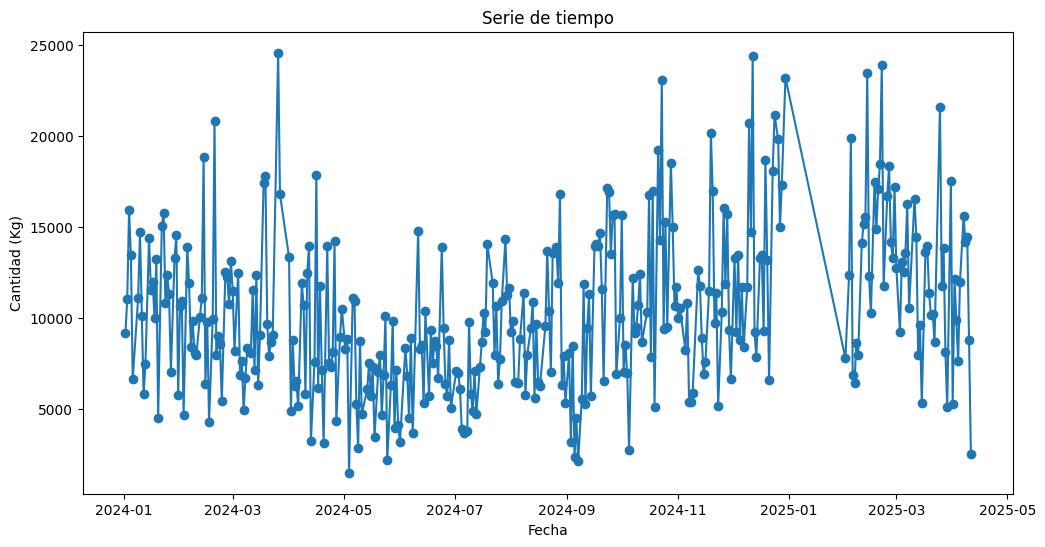

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["CANTIDAD"], label="KILOS", marker="o")
plt.title("Serie de tiempo")
plt.xlabel("Fecha")
plt.ylabel("Cantidad (Kg)")
plt.show()

In [ ]:
def adf_test(df, column_name):
    result = sm.tsa.adfuller(df.dropna())
    adf_statistic, p_value = result[0], result[1]

    print(f"\nPrueba de Dickey-Fuller para {column_name}:")
    print(f"Estadístico ADF: {adf_statistic}")
    print(f"Valor p: {p_value}")

    if p_value <= 0.05:
        print(f"La serie de tiempo '{column_name}' es ESTACIONARIA (p <= 0.05)")
    else:
        print(f"La serie de tiempo '{column_name}' NO es estacionaria (p > 0.05)")


adf_test(df["CANTIDAD"], "Cantidad")



Prueba de Dickey-Fuller para Cantidad:
Estadístico ADF: -3.2797519702119735
Valor p: 0.015808181454671968
La serie de tiempo 'Cantidad' es ESTACIONARIA (p <= 0.05)


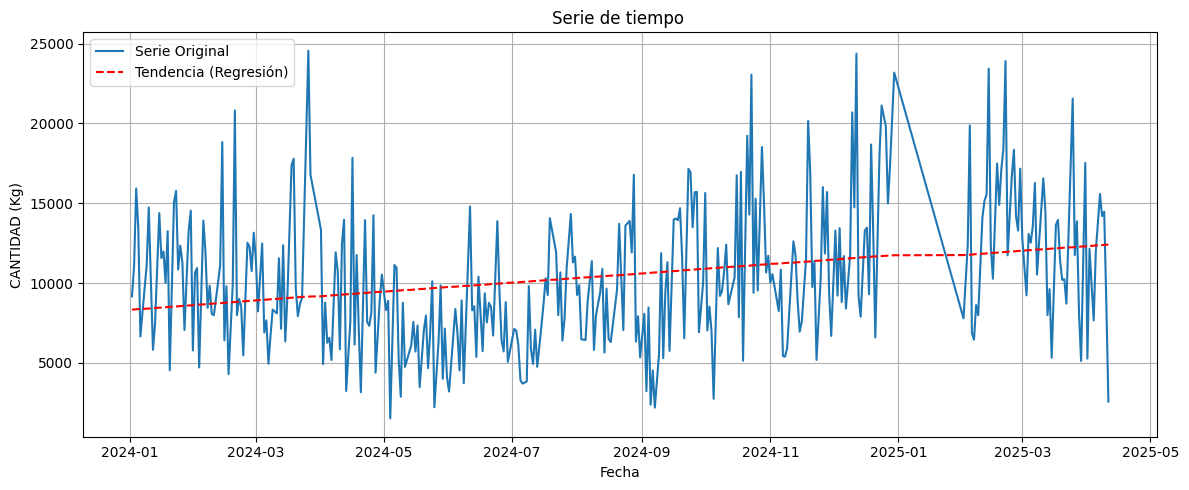

Tendencia creciente detectada (pendiente = 11.5854).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Cargar los datos
df = pd.read_excel("PredKi.xlsx", parse_dates=['Fecha'])
df = df[['Fecha', 'CANTIDAD']].dropna()
df.set_index('Fecha', inplace=True)

# Preparar los datos para regresión (convertir fechas en valores numéricos)
df['time_index'] = np.arange(len(df))
X = df[['time_index']]
y = df['CANTIDAD']

# Ajustar modelo de regresión lineal
modelo = LinearRegression()
modelo.fit(X, y)

# Obtener pendiente
pendiente = modelo.coef_[0]

# Agregar la línea de tendencia al gráfico
df['tendencia'] = modelo.predict(X)

# Mostrar el gráfico
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['CANTIDAD'], label='Serie Original')
plt.plot(df.index, df['tendencia'], color='red', linestyle='--', label='Tendencia (Regresión)')
plt.title('Serie de tiempo ')
plt.xlabel('Fecha')
plt.ylabel('CANTIDAD (Kg)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Ver resultado
if abs(pendiente) < 1e-3:
    print("No se detecta una tendencia significativa.")
elif pendiente > 0:
    print(f"Tendencia creciente detectada (pendiente = {pendiente:.4f}).")
else:
    print(f"Tendencia decreciente detectada (pendiente = {pendiente:.4f}).")

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp07seyr7d/18_q1og7.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp07seyr7d/4k87qz31.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=75867', 'data', 'file=/tmp/tmp07seyr7d/18_q1og7.json', 'init=/tmp/tmp07seyr7d/4k87qz31.json', 'output', 'file=/tmp/tmp07seyr7d/prophet_modelmz79_eqd/prophet_model-20250513225629.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
22:56:29 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:56:29 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.11/dist-packages/

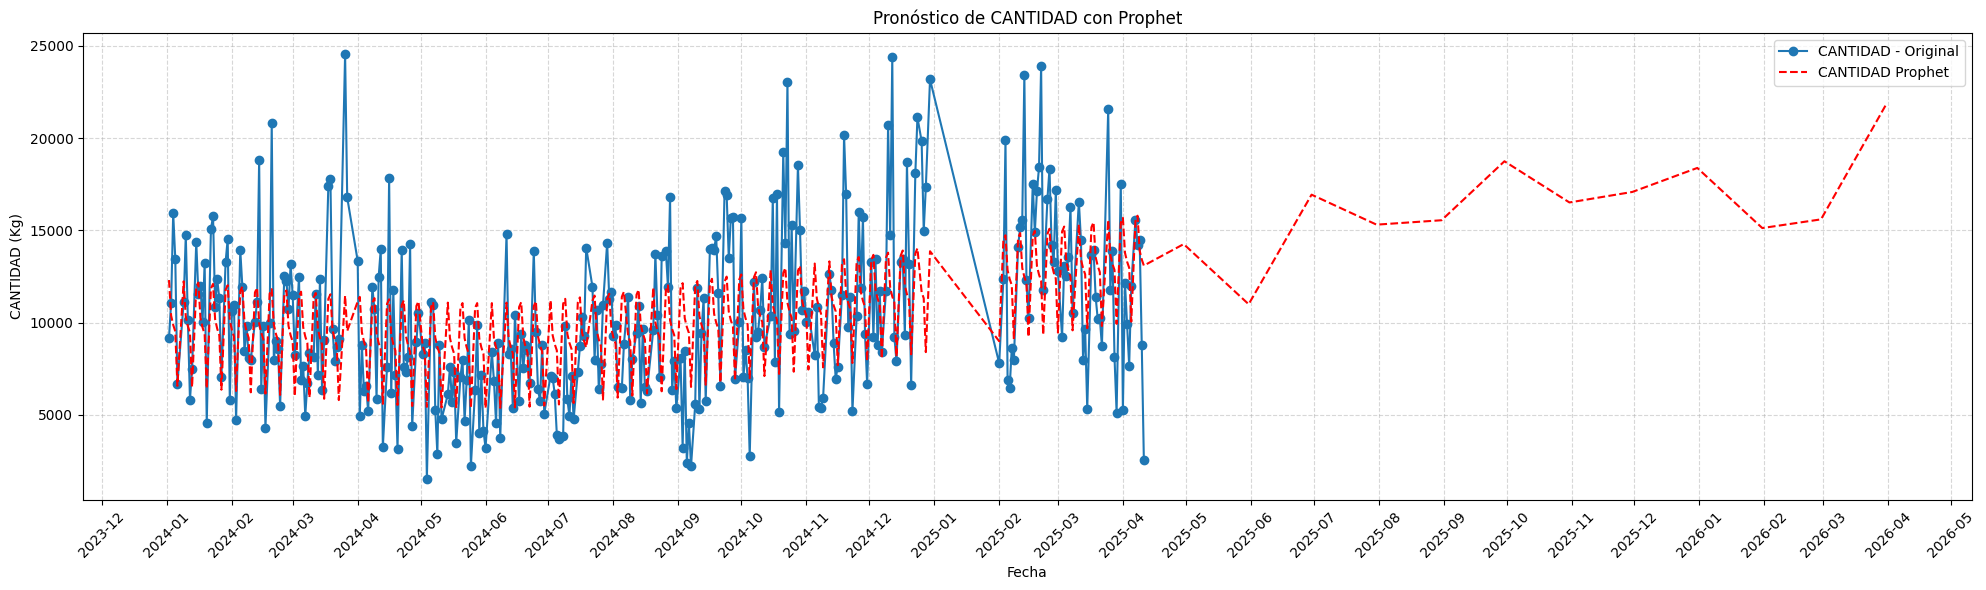

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet

# Cargar los datos
df = pd.read_excel("PredKi.xlsx", parse_dates=['Fecha'], header=0)
df["Fecha"] = pd.to_datetime(df["Fecha"])
df.set_index("Fecha", inplace=True)

# Preparar los datos para Prophet
df_prophet = df.reset_index().rename(columns={"Fecha": "ds", "CANTIDAD": "y"})

# Crear y ajustar el modelo Prophet
modelo = Prophet()
modelo.fit(df_prophet)

# Crear fechas futuras para el pronóstico (24 meses = 2 años, puedes ajustar)
future = modelo.make_future_dataframe(periods=12, freq='M')
forecast = modelo.predict(future)

# Graficar los resultados
plt.figure(figsize=(20, 6))

# Serie original
plt.plot(df_prophet['ds'], df_prophet['y'], label='CANTIDAD - Original', marker='o')

# Pronóstico
plt.plot(forecast['ds'], forecast['yhat'], label='CANTIDAD Prophet', linestyle='--', color='red')

# Ajustar formato del eje X para mostrar un mes por etiqueta
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))  # Una etiqueta cada mes
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # Formato Año-Mes

plt.title('Pronóstico de CANTIDAD con Prophet')
plt.xlabel('Fecha')
plt.ylabel('CANTIDAD (Kg)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
future = modelo.make_future_dataframe(periods=24, freq='M')
future = modelo.make_future_dataframe(periods=730, freq='D')  # 2 años diarios

# Predecir con fechas diarias
forecast = modelo.predict(future)

# Crear columna de mes
forecast['mes'] = forecast['ds'].dt.to_period('M')

# Filtrar solo las fechas futuras
ultima_fecha_real = df_prophet['ds'].max()
forecast_futuro = forecast[forecast['ds'] > ultima_fecha_real]

# Agrupar y sumar los valores por mes
sumatoria_mensual = forecast_futuro.groupby('mes')['yhat'].sum().round(2)

# Mostrar resultados
print("Sumatoria mensual del pronóstico (diario):")
print(sumatoria_mensual)



Sumatoria mensual del pronóstico (diario):
mes
2025-04    262238.58
2025-05    435711.50
2025-06    442610.85
2025-07    474130.09
2025-08    483508.86
2025-09    491832.74
2025-10    519455.12
2025-11    514556.48
2025-12    556239.48
2026-01    563753.19
2026-02    526843.80
2026-03    602495.76
2026-04    594992.80
2026-05    626183.89
2026-06    629905.35
2026-07    662130.15
2026-08    676761.10
2026-09    674782.48
2026-10    706428.21
2026-11    704594.76
2026-12    744846.80
2027-01    754225.58
2027-02    699139.53
2027-03    794031.18
2027-04    279460.37
Freq: M, Name: yhat, dtype: float64


/usr/local/lib/python3.11/dist-packages/prophet/forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [ ]:
# Convertir la serie a DataFrame
df_sumatoria = sumatoria_mensual.reset_index()
df_sumatoria.columns = ['Mes', 'Cantidad_Pronosticada']

# Exportar a Excel
df_sumatoria.to_excel("Pronostico_mensual.xlsx", index=False)

print("Archivo Excel guardado como 'Pronostico_mensual.xlsx'")

Archivo Excel guardado como 'Pronostico_mensual.xlsx'


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp07seyr7d/flowdv4n.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp07seyr7d/u4mjqisu.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=1834', 'data', 'file=/tmp/tmp07seyr7d/flowdv4n.json', 'init=/tmp/tmp07seyr7d/u4mjqisu.json', 'output', 'file=/tmp/tmp07seyr7d/prophet_modeljr3gevi2/prophet_model-20250513225446.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
22:54:46 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:54:46 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.11/dist-packages/p

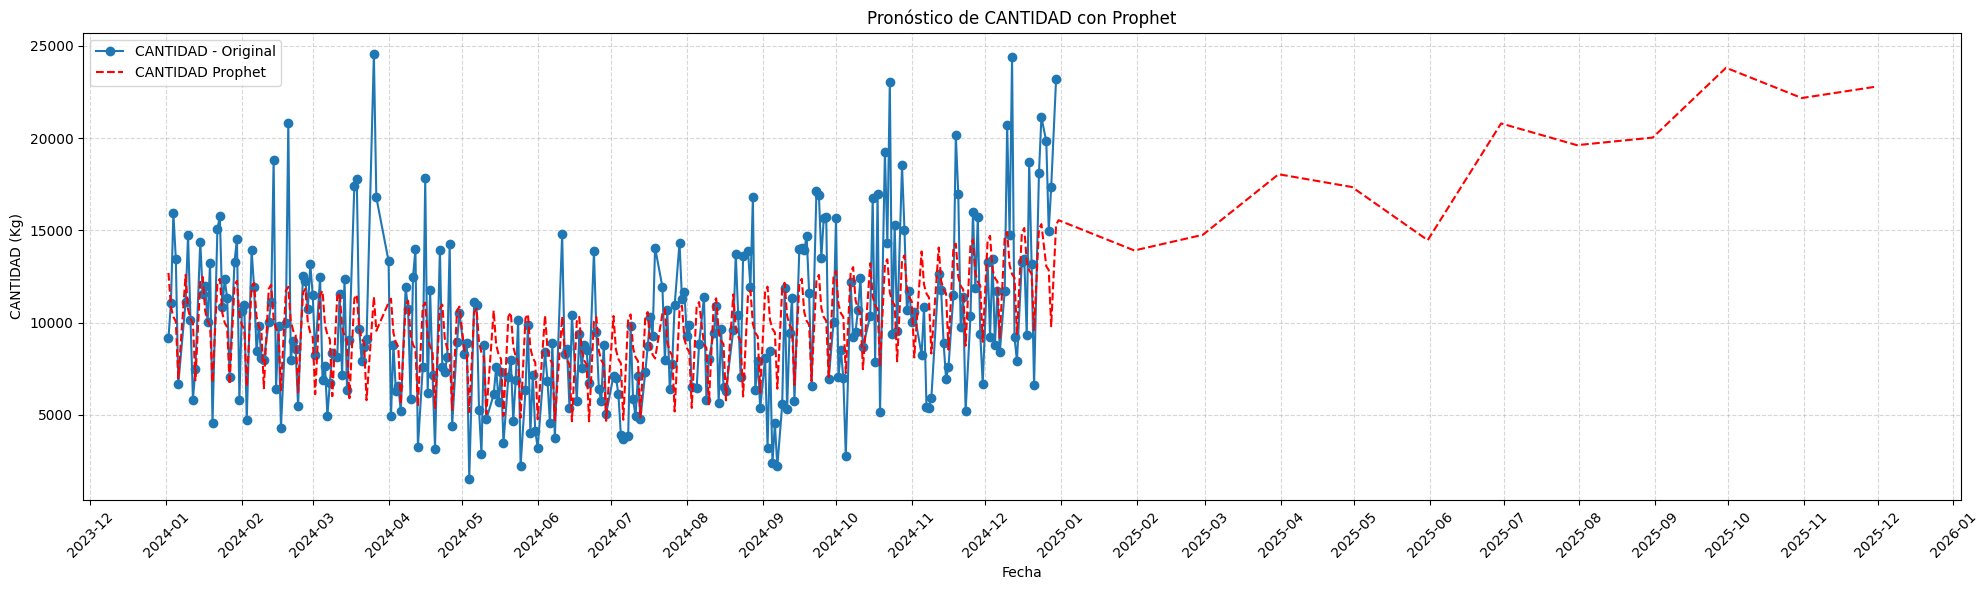

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet

# Cargar los datos
df = pd.read_excel("PredKi2.xlsx", parse_dates=['Fecha'], header=0)
df["Fecha"] = pd.to_datetime(df["Fecha"])
df.set_index("Fecha", inplace=True)

# Preparar los datos para Prophet
df_prophet = df.reset_index().rename(columns={"Fecha": "ds", "CANTIDAD": "y"})

# Crear y ajustar el modelo Prophet
modelo = Prophet()
modelo.fit(df_prophet)

# Crear fechas futuras para el pronóstico (24 meses = 2 años, puedes ajustar)
future = modelo.make_future_dataframe(periods=12, freq='M')
forecast = modelo.predict(future)

# Graficar los resultados
plt.figure(figsize=(20, 6))

# Serie original
plt.plot(df_prophet['ds'], df_prophet['y'], label='CANTIDAD - Original', marker='o')

# Pronóstico
plt.plot(forecast['ds'], forecast['yhat'], label='CANTIDAD Prophet', linestyle='--', color='red')

# Ajustar formato del eje X para mostrar un mes por etiqueta
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))  # Una etiqueta cada mes
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # Formato Año-Mes

plt.title('Pronóstico de CANTIDAD con Prophet')
plt.xlabel('Fecha')
plt.ylabel('CANTIDAD (Kg)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()